# EDA PROJECT

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\uciml\autompg-dataset\versions\3


In [3]:
import os
file_path = os.path.join(path, "auto-mpg.csv")
df_original = pd.read_csv(file_path)

## The purpose of this project's data analysis is to answer the two following questions:

### - How does car origin relate to car characteristics?
### - How does car origin influence characteristics evolution over time?

In [4]:
df = df_original.copy()

In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


Convert the column names to snake case.

In [7]:
df.columns = [col.lower().replace(" ", "_") for col in df.columns]

In [8]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [9]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [10]:
df.shape

(398, 9)

The variables were assigned as follows:

* **Categorical**: origin (few values + no numeric meaning), cylinders (the number of cylinders determine the engine type/configuration (i.e., category), not a continuous measure), and car_name;

* **Numerical**: mpg, horsepower, weight, displacement, acceleration, model_year (numeric meaning + ordered progression / trend - numerical (model_year)).

Verify if null values are present

In [11]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Verify is NaN values are present

In [12]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Verify if duplicates exist

In [13]:
df.duplicated().sum()

np.int64(0)

Verify the unique values of each column

In [14]:
df.nunique()

mpg             129
cylinders         5
displacement     82
horsepower       94
weight          351
acceleration     95
model_year       13
origin            3
car_name        305
dtype: int64

The dataset information states there are 6 missing horsepower values. However they were not detected in the first steps of EDA.

This investigation will be elaborated.

In [15]:
df["horsepower"].info

<bound method Series.info of 0      130
1      165
2      150
3      150
4      140
      ... 
393     86
394     52
395     84
396     79
397     82
Name: horsepower, Length: 398, dtype: object>

Horsepower was expected to be of int or float and not object. This indicates the presence of non-numerical values.

In [16]:
len(df.horsepower)

398

In [17]:
float(df.horsepower.str.isnumeric().sum())

392.0

There are 6 (398-392) non-numerical values in the horsepower column.

The dtype of the horsepower column values will be changed to numeric, which will replace the missing values with NaN.

In [18]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [20]:
int(df.horsepower.isna().sum())

6

As expected, the missing horsepower values (6) were converted to NaN.

The next step consists on deciding on how to deal with the missing values. The categories "cylinders", "displacement", "model_year", and "car_name" are expected to correlate with horsepower figures, so a new df will be created to display only relevant information.

In [21]:
df_missing_hp = df[["cylinders", "displacement", "horsepower", "model_year", "car_name"]]
df_missing_hp

,cylinders,displacement,horsepower,model_year,car_name
0,8,307.0,130.0,70,chevrolet chevelle malibu
1,8,350.0,165.0,70,buick skylark 320
2,8,318.0,150.0,70,plymouth satellite
3,8,304.0,150.0,70,amc rebel sst
4,8,302.0,140.0,70,ford torino
...,...,...,...,...,...
393,4,140.0,86.0,82,ford mustang gl
394,4,97.0,52.0,82,vw pickup
395,4,135.0,84.0,82,dodge rampage
396,4,120.0,79.0,82,ford ranger


In [22]:
df_missing_hp = df[["cylinders", "displacement", "horsepower", "model_year", "car_name"]]
df_missing_hp

,cylinders,displacement,horsepower,model_year,car_name
0,8,307.0,130.0,70,chevrolet chevelle malibu
1,8,350.0,165.0,70,buick skylark 320
2,8,318.0,150.0,70,plymouth satellite
3,8,304.0,150.0,70,amc rebel sst
4,8,302.0,140.0,70,ford torino
...,...,...,...,...,...
393,4,140.0,86.0,82,ford mustang gl
394,4,97.0,52.0,82,vw pickup
395,4,135.0,84.0,82,dodge rampage
396,4,120.0,79.0,82,ford ranger


In [23]:
car_missing_hp = df_missing_hp[df_missing_hp["horsepower"].isna()]
car_missing_hp

,cylinders,displacement,horsepower,model_year,car_name
32,4,98.0,NaN,71,ford pinto
126,6,200.0,NaN,74,ford maverick
330,4,85.0,NaN,80,renault lecar deluxe
336,4,140.0,NaN,80,ford mustang cobra
354,4,100.0,NaN,81,renault 18i
374,4,151.0,NaN,82,amc concord dl


Considering there could be multiples car name variations, the first step is to investigate how many there are for any given car name.

In [24]:
df[df['car_name'].str.contains('ford pinto', case=False, na=False)]['car_name'].value_counts()

car_name
ford pinto             6
ford pinto runabout    1
ford pinto (sw)        1
Name: count, dtype: int64

In [25]:
df_ford_pinto = df_missing_hp[df_missing_hp["car_name"] == "ford pinto"]
df_ford_pinto

,cylinders,displacement,horsepower,model_year,car_name
32,4,98.0,NaN,71,ford pinto
112,4,122.0,85.0,73,ford pinto
130,4,122.0,80.0,74,ford pinto
168,4,140.0,83.0,75,ford pinto
174,6,171.0,97.0,75,ford pinto
206,4,140.0,72.0,76,ford pinto


In [26]:
df_ford_pinto_r = df_missing_hp[df_missing_hp["car_name"] == "ford pinto runabout"]
df_ford_pinto_r

,cylinders,displacement,horsepower,model_year,car_name
61,4,122.0,86.0,72,ford pinto runabout


In [27]:
df_ford_pinto_sw = df_missing_hp[df_missing_hp["car_name"] == "ford pinto (sw)"]
df_ford_pinto_sw

,cylinders,displacement,horsepower,model_year,car_name
80,4,122.0,86.0,72,ford pinto (sw)


In [28]:
df_ford_pinto_concat = pd.concat([df_ford_pinto, df_ford_pinto_r, df_ford_pinto_sw])
df_ford_pinto_concat.sort_index()

,cylinders,displacement,horsepower,model_year,car_name
32,4,98.0,NaN,71,ford pinto
61,4,122.0,86.0,72,ford pinto runabout
80,4,122.0,86.0,72,ford pinto (sw)
112,4,122.0,85.0,73,ford pinto
130,4,122.0,80.0,74,ford pinto
168,4,140.0,83.0,75,ford pinto
174,6,171.0,97.0,75,ford pinto
206,4,140.0,72.0,76,ford pinto


With the assumption that there are no significant differences between Ford Pinto and its model variations (Runabout and SW), so they will be considered for estimating the missing horsepower value (#32).

The car with 6 cylinders (#174, Ford Pinto) will be dropped, considering the engine size may affect horsepower and the missing value corresponds to a car with 4 cylinders.

The car from the year 76 (#206, Ford Pinto) will also be dropped given the dispersion of horsepower compared to the remaining cars. This could be a change in model characteristics in said year.

In [29]:
df_ford_pinto_concat_dropped = df_ford_pinto_concat.drop(index=[174, 206])
df_ford_pinto_concat_dropped.sort_index()

,cylinders,displacement,horsepower,model_year,car_name
32,4,98.0,NaN,71,ford pinto
61,4,122.0,86.0,72,ford pinto runabout
80,4,122.0,86.0,72,ford pinto (sw)
112,4,122.0,85.0,73,ford pinto
130,4,122.0,80.0,74,ford pinto
168,4,140.0,83.0,75,ford pinto


The average values of the remaining cars will be used to estimate the missing horsepower value (#32, Ford Pinto) by using the average value.

In [30]:
avg_ford_pinto = float(df_ford_pinto_concat_dropped.horsepower.mean())
avg_ford_pinto

84.0

In [31]:
df.loc[32, 'horsepower']

np.float64(nan)

The average horsepower value of 84.0 will replace the NaN value in the original df, in row #32.

In [32]:
df.loc[32, 'horsepower'] = avg_ford_pinto
float(df.loc[32, 'horsepower'])

84.0

In [33]:
df.horsepower.isna().sum()

np.int64(5)

This investigation will be replicated for the remaining NaN values.

In [34]:
df[df['car_name'].str.contains('ford maverick', case=False, na=False)]['car_name'].value_counts()

car_name
ford maverick    5
Name: count, dtype: int64

In [35]:
df_ford_maverick = df_missing_hp[df_missing_hp["car_name"] == "ford maverick"]
df_ford_maverick


,cylinders,displacement,horsepower,model_year,car_name
17,6,200.0,85.0,70,ford maverick
100,6,250.0,88.0,73,ford maverick
126,6,200.0,NaN,74,ford maverick
155,6,250.0,72.0,75,ford maverick
193,6,200.0,81.0,76,ford maverick


Considering the car with index 155 has a horsepower figure significantly different from the remaining cars, it will not be considered for estimating the NaN horsepower value.

In [36]:
df_ford_maverick_dropped = df_ford_maverick.drop(index=155)
df_ford_maverick_dropped

,cylinders,displacement,horsepower,model_year,car_name
17,6,200.0,85.0,70,ford maverick
100,6,250.0,88.0,73,ford maverick
126,6,200.0,NaN,74,ford maverick
193,6,200.0,81.0,76,ford maverick


In [37]:
avg_ford_maverick = round(float(df_ford_maverick_dropped.horsepower.mean()), 1)
avg_ford_maverick

84.7

The average horsepower value of 84.7 will replace the NaN value in the original df, in row 126.

In [38]:
df.loc[126, 'horsepower']

np.float64(nan)

In [39]:
df.loc[126, 'horsepower'] = avg_ford_maverick
float(df.loc[126, 'horsepower'])

84.7

In [40]:
df[df['car_name'].str.contains('renault', case=False, na=False)]['car_name'].value_counts()

car_name
renault 12 (sw)         1
renault 12tl            1
renault 5 gtl           1
renault lecar deluxe    1
renault 18i             1
Name: count, dtype: int64

In [41]:
df_renault_lecar_deluxe = df_missing_hp[df_missing_hp["car_name"] == "renault lecar deluxe"]
df_renault_lecar_deluxe

,cylinders,displacement,horsepower,model_year,car_name
330,4,85.0,NaN,80,renault lecar deluxe


In [42]:
df_renault_18i = df_missing_hp[df_missing_hp["car_name"] == "renault 18i"]
df_renault_18i

,cylinders,displacement,horsepower,model_year,car_name
354,4,100.0,NaN,81,renault 18i


In [43]:
df_renault_12sw = df_missing_hp[df_missing_hp["car_name"] == "renault 12 (sw)"]
df_renault_12sw

,cylinders,displacement,horsepower,model_year,car_name
79,4,96.0,69.0,72,renault 12 (sw)


In [44]:
df_renault_12tl = df_missing_hp[df_missing_hp["car_name"] == "renault 12tl"]
df_renault_12tl

,cylinders,displacement,horsepower,model_year,car_name
186,4,101.0,83.0,76,renault 12tl


In [45]:
df_renault_5gtl = df_missing_hp[df_missing_hp["car_name"] == "renault 5 gtl"]
df_renault_5gtl

,cylinders,displacement,horsepower,model_year,car_name
218,4,79.0,58.0,77,renault 5 gtl


In [46]:
df_renault_concat = pd.concat([df_renault_lecar_deluxe, df_renault_18i, df_renault_12sw, df_renault_12tl, df_renault_5gtl])
df_renault_concat.sort_index()

,cylinders,displacement,horsepower,model_year,car_name
79,4,96.0,69.0,72,renault 12 (sw)
186,4,101.0,83.0,76,renault 12tl
218,4,79.0,58.0,77,renault 5 gtl
330,4,85.0,NaN,80,renault lecar deluxe
354,4,100.0,NaN,81,renault 18i


As the car models are different and unique and there is a wide spread of horsepower values, thus no reliable estimate can be performed for the NaN values.

Therefore, the rows 330 and 354 will be dropped from the original df.

In [47]:
df = df.drop(index=[330, 354])

In [48]:
df.shape

(396, 9)

The df.shape shows the successfull elimination of 2 rows.

In [49]:
df[df['car_name'].str.contains('ford mustang', case=False, na=False)]['car_name'].value_counts()

car_name
ford mustang           1
ford mustang ii        1
ford mustang ii 2+2    1
ford mustang cobra     1
ford mustang gl        1
Name: count, dtype: int64

In [50]:
df_ford_mustang = df_missing_hp[df_missing_hp["car_name"] == "ford mustang"]
df_ford_mustang

,cylinders,displacement,horsepower,model_year,car_name
48,6,250.0,88.0,71,ford mustang


In [51]:
df_ford_mustang_ii = df_missing_hp[df_missing_hp["car_name"] == "ford mustang ii"]
df_ford_mustang_ii

,cylinders,displacement,horsepower,model_year,car_name
166,8,302.0,129.0,75,ford mustang ii


In [52]:
df_ford_mustang_ii22 = df_missing_hp[df_missing_hp["car_name"] == "ford mustang ii 2+2"]
df_ford_mustang_ii22

,cylinders,displacement,horsepower,model_year,car_name
236,4,140.0,89.0,77,ford mustang ii 2+2


In [53]:
df_ford_mustang_cobra = df_missing_hp[df_missing_hp["car_name"] == "ford mustang cobra"]
df_ford_mustang_cobra

,cylinders,displacement,horsepower,model_year,car_name
336,4,140.0,NaN,80,ford mustang cobra


In [54]:
df_ford_mustang_gl = df_missing_hp[df_missing_hp["car_name"] == "ford mustang gl"]
df_ford_mustang_gl

,cylinders,displacement,horsepower,model_year,car_name
393,4,140.0,86.0,82,ford mustang gl


In [55]:
df_ford_mustang_concat = pd.concat([df_ford_mustang, df_ford_mustang_ii, df_ford_mustang_ii22, df_ford_mustang_cobra, df_ford_mustang_gl])
df_ford_mustang_concat

,cylinders,displacement,horsepower,model_year,car_name
48,6,250.0,88.0,71,ford mustang
166,8,302.0,129.0,75,ford mustang ii
236,4,140.0,89.0,77,ford mustang ii 2+2
336,4,140.0,NaN,80,ford mustang cobra
393,4,140.0,86.0,82,ford mustang gl


The cars with 6 and 8 cylinders (#48 and 166) will be dropped, considering the engine size may affect horsepower and the missing value corresponds to a car with 4 cylinders. Car 166 also has a significantly higher horsepower figure, which would affect the horsepower average.

In [56]:
df_ford_mustang_concat_dropped = df_ford_mustang_concat.drop(index=[48, 166])
df_ford_mustang_concat_dropped

,cylinders,displacement,horsepower,model_year,car_name
236,4,140.0,89.0,77,ford mustang ii 2+2
336,4,140.0,NaN,80,ford mustang cobra
393,4,140.0,86.0,82,ford mustang gl


In [57]:
avg_ford_mustang = df_ford_mustang_concat_dropped["horsepower"].mean()
avg_ford_mustang = round(float(avg_ford_mustang), 1)
avg_ford_mustang

87.5

In [58]:
df.loc[336, 'horsepower']

np.float64(nan)

In [59]:
df.loc[336, 'horsepower'] = avg_ford_mustang
df.loc[336, 'horsepower']

np.float64(87.5)

In [60]:
df['horsepower'].isna().sum()

np.int64(1)

In [61]:
df[df['car_name'].str.contains('amc concord', case=False, na=False)]['car_name'].value_counts()

car_name
amc concord         2
amc concord d/l     1
amc concord dl 6    1
amc concord dl      1
Name: count, dtype: int64

In [62]:
df_amc_concord = df_missing_hp[df_missing_hp["car_name"] == "amc concord"]
df_amc_concord

,cylinders,displacement,horsepower,model_year,car_name
257,6,232.0,90.0,78,amc concord
315,4,151.0,90.0,80,amc concord


In [63]:
df_amc_concord_dl = df_missing_hp[df_missing_hp["car_name"] == "amc concord dl"]
df_amc_concord_dl

,cylinders,displacement,horsepower,model_year,car_name
374,4,151.0,NaN,82,amc concord dl


In [64]:
df_amc_concord_dl6 = df_missing_hp[df_missing_hp["car_name"] == "amc concord dl 6"]
df_amc_concord_dl6

,cylinders,displacement,horsepower,model_year,car_name
283,6,232.0,90.0,79,amc concord dl 6


In [65]:
df_amc_concord_d_l = df_missing_hp[df_missing_hp["car_name"] == "amc concord d/l"]
df_amc_concord_d_l

,cylinders,displacement,horsepower,model_year,car_name
261,6,258.0,120.0,78,amc concord d/l


In [66]:
df_amc_concord_concat = pd.concat([df_amc_concord, df_amc_concord_dl, df_amc_concord_dl6, df_amc_concord_d_l])
df_amc_concord_concat.sort_index()

,cylinders,displacement,horsepower,model_year,car_name
257,6,232.0,90.0,78,amc concord
261,6,258.0,120.0,78,amc concord d/l
283,6,232.0,90.0,79,amc concord dl 6
315,4,151.0,90.0,80,amc concord
374,4,151.0,NaN,82,amc concord dl


The cars with 6 cylinders (257, 261, and 283) will be dropped, considering the engine size may affect horsepower and the missing value corresponds to a car with 4 cylinders.

The dl version is a different trim of the base AMC Concord, so for the NaN value the figure of 90 hp (equal to car 315) will be assumed.

In [67]:
df.loc[315, 'horsepower']

np.float64(90.0)

In [68]:
df.loc[374, 'horsepower']

np.float64(nan)

In [69]:
df.loc[374, 'horsepower'] = df.loc[315, 'horsepower']
df.loc[374, 'horsepower']

np.float64(90.0)

In [70]:
df['horsepower'].isna().sum()

np.int64(0)

In [71]:
df.cylinders.value_counts()

cylinders
4    202
8    103
6     84
3      4
5      3
Name: count, dtype: int64

In [72]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


For an easier representation of the statistical parameters, the original df will be separated according to the origin, creating 3 new df.

In [73]:
df_origin_1 = df[df["origin"] == 1]
df_origin_1

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,151.0,90.0,2950,17.3,82,1,chevrolet camaro
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [74]:
df_origin_1.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.0
mean,20.083534,6.248996,245.901606,118.526908,3361.931727,15.033735,75.610442,1.0
std,6.402892,1.661425,98.501839,39.787085,794.792506,2.751112,3.677094,0.0
min,9.000000,4.000000,85.000000,52.000000,1800.000000,8.000000,70.000000,1.0
25%,15.000000,4.000000,151.000000,88.000000,2720.000000,13.000000,73.000000,1.0
50%,18.500000,6.000000,250.000000,105.000000,3365.000000,15.000000,76.000000,1.0
75%,24.000000,8.000000,318.000000,150.000000,4054.000000,16.900000,79.000000,1.0
max,39.000000,8.000000,455.000000,230.000000,5140.000000,22.200000,82.000000,1.0


In [75]:
df_origin_2 = df[df["origin"] == 2]
df_origin_2

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
19,26.0,4,97.0,46.0,1835,20.5,70,2,volkswagen 1131 deluxe sedan
20,25.0,4,110.0,87.0,2672,17.5,70,2,peugeot 504
21,24.0,4,107.0,90.0,2430,14.5,70,2,audi 100 ls
22,25.0,4,104.0,95.0,2375,17.5,70,2,saab 99e
23,26.0,4,121.0,113.0,2234,12.5,70,2,bmw 2002
...,...,...,...,...,...,...,...,...,...
353,33.0,4,105.0,74.0,2190,14.2,81,2,volkswagen jetta
359,28.1,4,141.0,80.0,3230,20.4,81,2,peugeot 505s turbo diesel
360,30.7,6,145.0,76.0,3160,19.6,81,2,volvo diesel
375,36.0,4,105.0,74.0,1980,15.3,82,2,volkswagen rabbit l


In [76]:
df_origin_2.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.0
mean,27.602941,4.161765,109.632353,80.558824,2433.470588,16.794118,75.676471,2.0
std,6.580182,0.506975,22.693220,20.157871,491.813867,3.087813,3.422669,0.0
min,16.200000,4.000000,68.000000,46.000000,1825.000000,12.200000,70.000000,2.0
25%,23.750000,4.000000,94.750000,69.750000,2071.750000,14.500000,73.000000,2.0
50%,26.000000,4.000000,105.000000,76.500000,2240.000000,15.600000,76.000000,2.0
75%,30.125000,4.000000,121.000000,90.000000,2803.750000,19.125000,78.250000,2.0
max,44.300000,6.000000,183.000000,133.000000,3820.000000,24.800000,82.000000,2.0


In [77]:
df_origin_3 = df[df["origin"] == 3]
df_origin_3

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
14,24.0,4,113.0,95.0,2372,15.0,70,3,toyota corona mark ii
18,27.0,4,97.0,88.0,2130,14.5,70,3,datsun pl510
29,27.0,4,97.0,88.0,2130,14.5,71,3,datsun pl510
31,25.0,4,113.0,95.0,2228,14.0,71,3,toyota corona
53,31.0,4,71.0,65.0,1773,19.0,71,3,toyota corolla 1200
...,...,...,...,...,...,...,...,...,...
382,34.0,4,108.0,70.0,2245,16.9,82,3,toyota corolla
383,38.0,4,91.0,67.0,1965,15.0,82,3,honda civic
384,32.0,4,91.0,67.0,1965,15.7,82,3,honda civic (auto)
385,38.0,4,91.0,67.0,1995,16.2,82,3,datsun 310 gx


In [78]:
df_origin_3.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.0
mean,30.450633,4.101266,102.708861,79.835443,2221.227848,16.172152,77.443038,3.0
std,6.090048,0.590414,23.140126,17.819199,320.497248,1.954937,3.650595,0.0
min,18.000000,3.000000,70.000000,52.000000,1613.000000,11.400000,70.000000,3.0
25%,25.700000,4.000000,86.000000,67.000000,1985.000000,14.600000,74.000000,3.0
50%,31.600000,4.000000,97.000000,75.000000,2155.000000,16.400000,78.000000,3.0
75%,34.050000,4.000000,119.000000,95.000000,2412.500000,17.550000,81.000000,3.0
max,46.600000,6.000000,168.000000,132.000000,2930.000000,21.000000,82.000000,3.0


The outliers present in the original df were investigated.

In [79]:
def id_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    
    print(f"The column {column.name} has these outliers:")
    print(outliers)
    print()

In [80]:
def count_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return ((column < lower_bound) | (column > upper_bound)).sum()

In [81]:
for col in df.select_dtypes(include='number').columns:
    if count_outliers(df[col]) > 0:
        id_outliers(df[col])

The column mpg has these outliers:
322    46.6
Name: mpg, dtype: float64

The column horsepower has these outliers:
6      220.0
7      215.0
8      225.0
13     225.0
25     215.0
26     200.0
27     210.0
67     208.0
94     215.0
95     225.0
116    230.0
Name: horsepower, dtype: float64

The column acceleration has these outliers:
7       8.5
9       8.5
11      8.0
59     23.5
195    22.2
299    24.8
300    22.2
326    23.7
394    24.6
Name: acceleration, dtype: float64



In [82]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000
mean,23.442929,5.462121,193.935606,104.288384,2974.934343,15.563131,75.987374,1.570707
std,7.766792,1.702144,104.283882,38.338526,846.414146,2.763259,3.692941,0.803505
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.375000,4.000000,105.000000,75.750000,2225.250000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,151.000000,92.000000,2811.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,263.250000,125.000000,3610.000000,17.125000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [83]:
#Relationship between median and mean of mpg
(1-23/23.4)*100

1.7094017094017033

In [84]:
#Relationship between median and mean of horsepower
(1-92/104.3)*100

11.792905081495686

In [85]:
#Relationship between median and mean of acceleration
(1-15.5/15.6)*100

0.6410256410256387

Considering the outliers seem to have a greater impact on horsepower, they will be dropped from the original df.

In [86]:
df_clean = df.drop(index=[6, 7, 8, 13, 25, 26, 27, 67, 94, 95, 116])
df_clean.shape

(385, 9)

The shape shows the successful elimination of horsepower outlier rows and the outlier_id function will be called again.

In [87]:
for col in df.select_dtypes(include='number').columns:
    if count_outliers(df_clean[col]) > 0:
        id_outliers(df_clean[col])

The column mpg has these outliers:
322    46.6
Name: mpg, dtype: float64

The column horsepower has these outliers:
5      198.0
9      190.0
28     193.0
42     180.0
70     190.0
90     198.0
106    180.0
124    180.0
212    180.0
229    180.0
231    190.0
Name: horsepower, dtype: float64

The column acceleration has these outliers:
9       8.5
11      8.0
59     23.5
299    24.8
326    23.7
394    24.6
Name: acceleration, dtype: float64



Considering that the elimination of the horsepower outliers in the original df does not solve the issue in the said column since new outliers arise, the original df with the 2 previsouly dropped rows will be considered for data analysis.

# Univariate Analysis

For an easier understanding of origin, the numbers will be shown as the respective country/region.

In [88]:
df['origin'] = df['origin'].map({
    1: 'USA',
    2: 'Europe',
    3: 'Japan'
})

### The following section includes the analysis of categorial variables

In [89]:
frequency_table_origin = df["origin"].value_counts()
frequency_table_origin

origin
USA       249
Japan      79
Europe     68
Name: count, dtype: int64

In [90]:
proportion_table_origin = df.origin.value_counts(normalize=True).round(2)
proportion_table_origin

origin
USA       0.63
Japan     0.20
Europe    0.17
Name: proportion, dtype: float64

In [91]:
table_origin = pd.concat([frequency_table_origin, proportion_table_origin], axis=1)
table_origin.columns = ['absolute_frequency', 'relative_frequency']
table_origin

,absolute_frequency,relative_frequency
origin,,
USA,249,0.63
Japan,79,0.20
Europe,68,0.17


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\1495190950.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


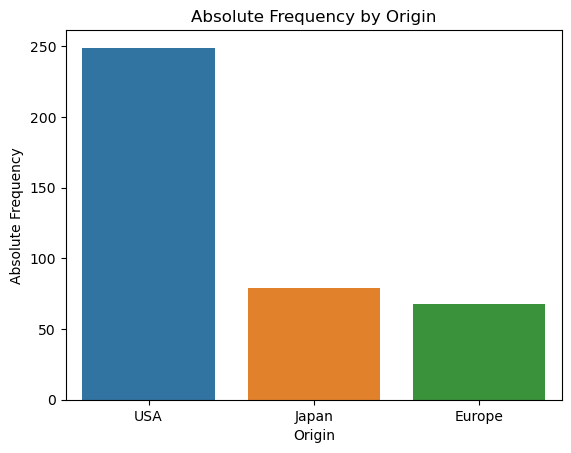

In [92]:
sns.barplot(
    x="origin",
    y='absolute_frequency',
    data=table_origin,
    palette='tab10',
    legend=True,
)
plt.xlabel("Origin")
plt.ylabel("Absolute Frequency")
plt.title("Absolute Frequency by Origin")
plt.show()

Most cars in the dataset originate from the USA (63%), followed by Japan (20%), and then Europe (17%).

In [93]:
frequency_table_cylinders = df["cylinders"].value_counts()
frequency_table_cylinders

cylinders
4    202
8    103
6     84
3      4
5      3
Name: count, dtype: int64

In [94]:
proportion_table_cylinders = df["cylinders"].value_counts(normalize=True).round(2)
proportion_table_cylinders

cylinders
4    0.51
8    0.26
6    0.21
3    0.01
5    0.01
Name: proportion, dtype: float64

In [95]:
table_cylinders = pd.concat([frequency_table_cylinders, proportion_table_cylinders], axis=1)
table_cylinders.columns = ['absolute_frequency', 'relative_frequency']
table_cylinders

,absolute_frequency,relative_frequency
cylinders,,
4,202,0.51
8,103,0.26
6,84,0.21
3,4,0.01
5,3,0.01


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\1369200235.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


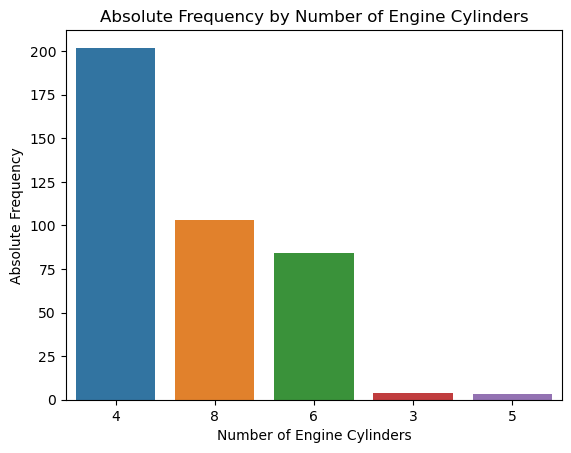

In [96]:
order = df['cylinders'].value_counts().index

sns.barplot(
    x="cylinders",
    y='absolute_frequency',
    data=table_cylinders,
    order=order,
    palette='tab10',
    legend=True,
)
plt.xlabel("Number of Engine Cylinders")
plt.ylabel("Absolute Frequency")
plt.title("Absolute Frequency by Number of Engine Cylinders")
plt.show()

Most cars in the dataset have 4 engine cylinders (51%), followed by 8 engine cylinders (26%), and 6 engine cylinders (21%). Engine configurations with 3 and 5 cylinders have a residual expression (~1%)

In [97]:
frequency_table_car_name = df["car_name"].value_counts()
frequency_table_car_name

car_name
ford pinto             6
amc matador            5
toyota corolla         5
ford maverick          5
amc hornet             4
                      ..
chevrolet monza 2+2    1
ford mustang ii        1
pontiac astro          1
amc pacer              1
chevy s-10             1
Name: count, Length: 303, dtype: int64

In [98]:
proportion_table_car_name = df["car_name"].value_counts(normalize=True).round(2)
proportion_table_car_name

car_name
ford pinto             0.02
amc matador            0.01
toyota corolla         0.01
ford maverick          0.01
amc hornet             0.01
                       ... 
chevrolet monza 2+2    0.00
ford mustang ii        0.00
pontiac astro          0.00
amc pacer              0.00
chevy s-10             0.00
Name: proportion, Length: 303, dtype: float64

In [99]:
table_car_name = pd.concat([frequency_table_car_name, proportion_table_car_name], axis=1)
table_car_name.columns = ['absolute_frequency', 'relative_frequency']
table_car_name

,absolute_frequency,relative_frequency
car_name,,
ford pinto,6,0.02
amc matador,5,0.01
toyota corolla,5,0.01
ford maverick,5,0.01
amc hornet,4,0.01
...,...,...
chevrolet monza 2+2,1,0.00
ford mustang ii,1,0.00
pontiac astro,1,0.00


In [100]:
table_car_name_top10 = table_car_name[0:10]
table_car_name_top10.columns = ['absolute_frequency', 'relative_frequency']
table_car_name_top10


,absolute_frequency,relative_frequency
car_name,,
ford pinto,6,0.02
amc matador,5,0.01
toyota corolla,5,0.01
ford maverick,5,0.01
amc hornet,4,0.01
toyota corona,4,0.01
chevrolet impala,4,0.01
amc gremlin,4,0.01
peugeot 504,4,0.01


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\1496290448.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


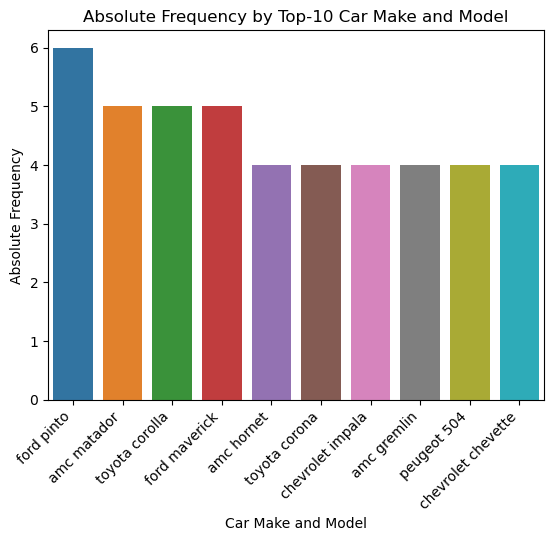

In [101]:
sns.barplot(
    x="car_name",
    y='absolute_frequency',
    data=table_car_name_top10,
    palette='tab10',
    legend=True,
)
plt.xlabel("Car Make and Model")
plt.ylabel("Absolute Frequency")
plt.title("Absolute Frequency by Top-10 Car Make and Model")
plt.xticks(rotation=45, ha='right')
plt.show()

Ford Pinto is the most common car name in the dataset, with 6 entries, followed by AMC Matador, Toyota Corolla, and Ford Maverick, all with 5 entries.

### The following section includes the analysis of continuous variables

In [102]:
#Create a new df containing just the continuous variables, for an easier visualization of statistical parameters
df_cont = df[["mpg", "displacement", "horsepower", "weight", "acceleration", "model_year"]]

In [103]:
df_cont.head()

,mpg,displacement,horsepower,weight,acceleration,model_year
0,18.0,307.0,130.0,3504,12.0,70
1,15.0,350.0,165.0,3693,11.5,70
2,18.0,318.0,150.0,3436,11.0,70
3,16.0,304.0,150.0,3433,12.0,70
4,17.0,302.0,140.0,3449,10.5,70


In [104]:
df_cont.info()

<class 'pandas.core.frame.DataFrame'>
Index: 396 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           396 non-null    float64
 1   displacement  396 non-null    float64
 2   horsepower    396 non-null    float64
 3   weight        396 non-null    int64  
 4   acceleration  396 non-null    float64
 5   model_year    396 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 37.8 KB


In [105]:
round(df_cont.describe(), 1)

,mpg,displacement,horsepower,weight,acceleration,model_year
count,396.0,396.0,396.0,396.0,396.0,396.0
mean,23.4,193.9,104.3,2974.9,15.6,76.0
std,7.8,104.3,38.3,846.4,2.8,3.7
min,9.0,68.0,46.0,1613.0,8.0,70.0
25%,17.4,105.0,75.8,2225.2,13.8,73.0
50%,23.0,151.0,92.0,2811.0,15.5,76.0
75%,29.0,263.2,125.0,3610.0,17.1,79.0
max,46.6,455.0,230.0,5140.0,24.8,82.0


In [106]:
round(df_cont.describe().T, 1)

,count,mean,std,min,25%,50%,75%,max
mpg,396.0,23.4,7.8,9.0,17.4,23.0,29.0,46.6
displacement,396.0,193.9,104.3,68.0,105.0,151.0,263.2,455.0
horsepower,396.0,104.3,38.3,46.0,75.8,92.0,125.0,230.0
weight,396.0,2974.9,846.4,1613.0,2225.2,2811.0,3610.0,5140.0
acceleration,396.0,15.6,2.8,8.0,13.8,15.5,17.1,24.8
model_year,396.0,76.0,3.7,70.0,73.0,76.0,79.0,82.0


In [107]:
for col in df_cont.columns:
    mode_column = df_cont[col].mode()[0]
    print(f"The column {col} has {mode_column} as mode.")

The column mpg has 13.0 as mode.
The column displacement has 97.0 as mode.
The column horsepower has 150.0 as mode.
The column weight has 1985 as mode.
The column acceleration has 14.5 as mode.
The column model_year has 73 as mode.


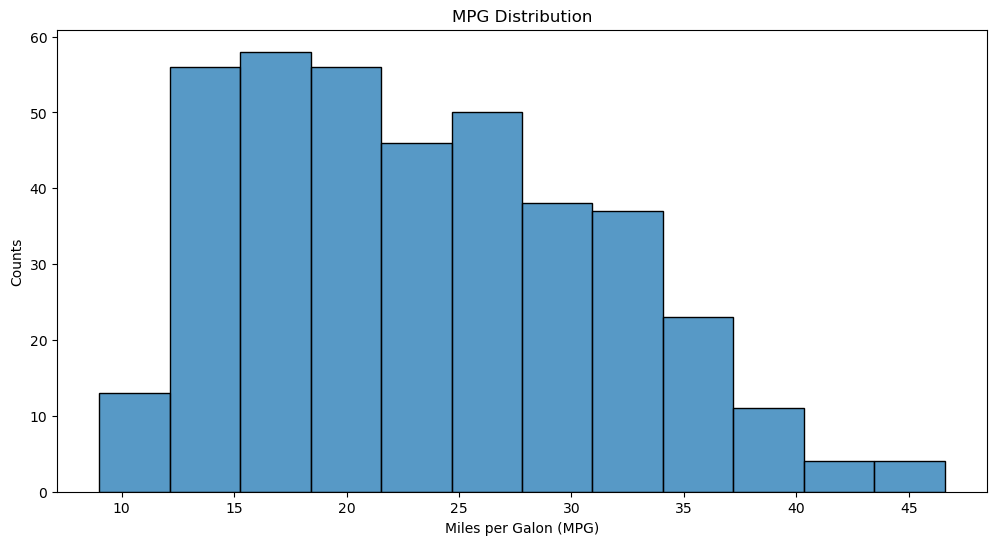

In [108]:
plt.figure(figsize=(12,6))
sns.histplot(df.mpg, bins="auto")
plt.xticks()
plt.xlabel("Miles per Galon (MPG)")
plt.ylabel("Counts")
plt.title("MPG Distribution")
plt.show()

In [109]:
round(float(df["mpg"].skew()), 2)

0.46

The distribution of MPG values shows a right/positive skew, indicating the bulk of the data is concentrated on the lower MPG values, with a tail extending to higher MPG values.

Most values are included in the range ~12-28 mpg.

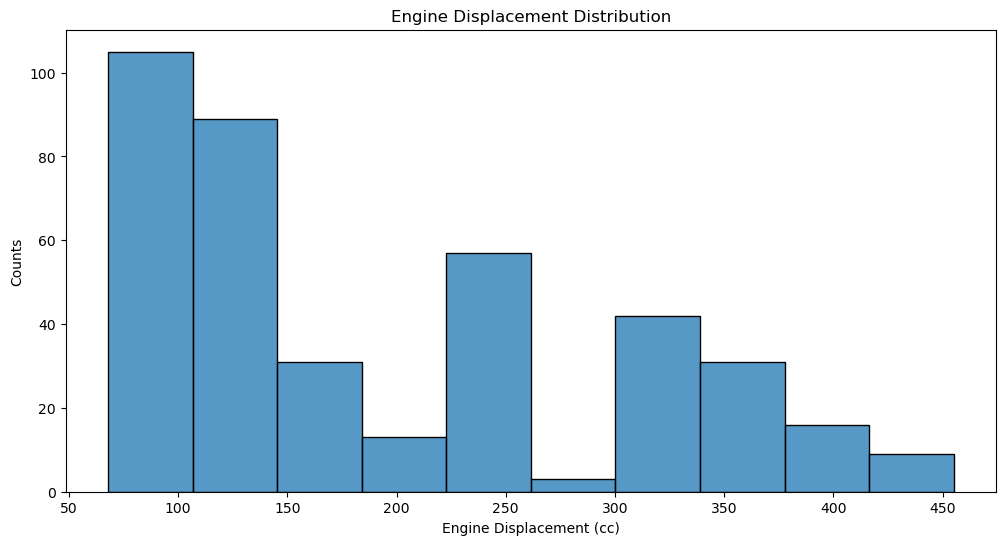

In [110]:
plt.figure(figsize=(12,6))
sns.histplot(df.displacement, bins="auto")
plt.xticks()
plt.xlabel("Engine Displacement (cc)")
plt.ylabel("Counts")
plt.title("Engine Displacement Distribution")
plt.show()

In [111]:
round(float(df["displacement"].skew()), 2)

0.71

The distribution of engine displacement values shows a right/positive skew, indicating the bulk of the data is concentrated on the lower engine displacement values, with a tail extending to higher engine displacement values.
A drop of counts is observed for ranges -150-225 cc and ~260-300 cc.

Most values are included in the range ~70-150 cc.

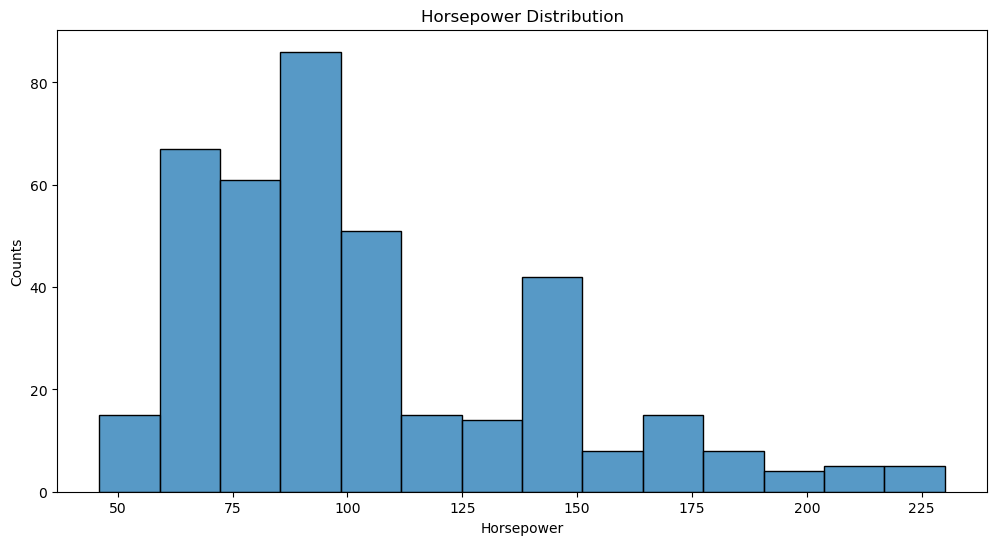

In [112]:
plt.figure(figsize=(12,6))
sns.histplot(df.horsepower, bins="auto")
plt.xticks()
plt.xlabel("Horsepower")
plt.ylabel("Counts")
plt.title("Horsepower Distribution")
plt.show()

In [113]:
round(float(df["horsepower"].skew()), 2)

1.1

The distribution of horsepowers values shows a  marked right/positive skew, indicating the bulk of the data is concentrated on the lower horsepower values, with a tail extending to higher horsepower values.

Most values are included in the range ~65-110 horsepower.

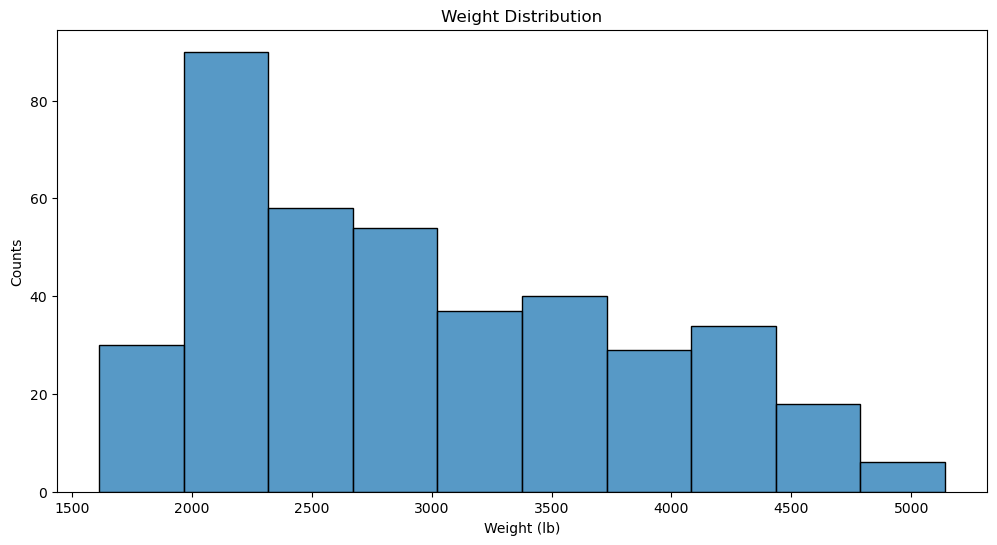

In [114]:
plt.figure(figsize=(12,6))
sns.histplot(df.weight, bins="auto")
plt.xticks()
plt.xlabel("Weight (lb)")
plt.ylabel("Counts")
plt.title("Weight Distribution")
plt.show()

In [115]:
round(float(df["weight"].skew()), 2)

0.53

The distribution of weight values shows a right/positive skew, indicating the bulk of the data is concentrated on the lower weight values, with a tail extending to higher weight values.

Most values are included in the range ~2000-3000 lb.

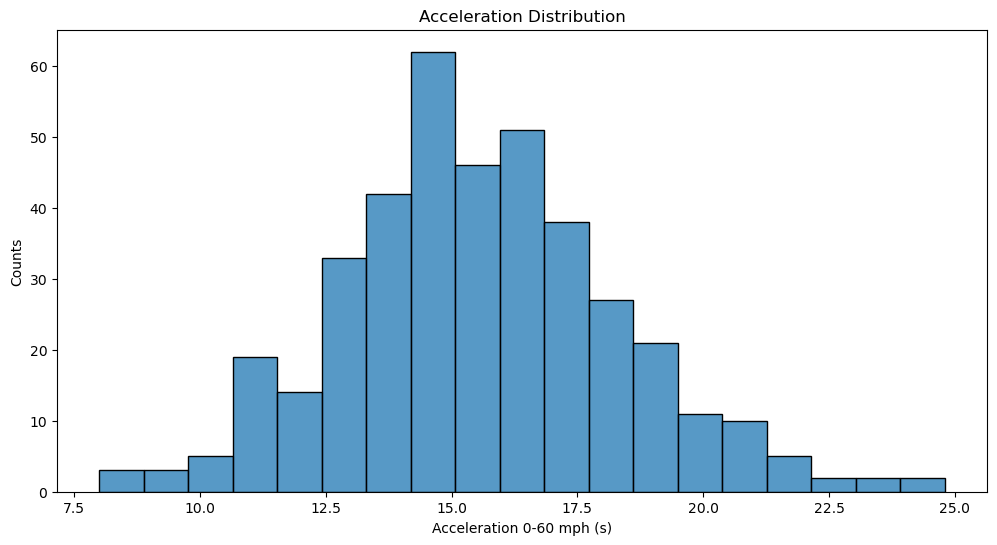

In [116]:
plt.figure(figsize=(12,6))
sns.histplot(df.acceleration, bins="auto")
plt.xticks()
plt.xlabel("Acceleration 0-60 mph (s)")
plt.ylabel("Counts")
plt.title("Acceleration Distribution")
plt.show()

In [117]:
round(float(df["acceleration"].skew()), 2)

0.28

In [118]:
df_cont.acceleration.describe()

count    396.000000
mean      15.563131
std        2.763259
min        8.000000
25%       13.800000
50%       15.500000
75%       17.125000
max       24.800000
Name: acceleration, dtype: float64

In [119]:
df_cont.acceleration.mode()

0    14.5
Name: acceleration, dtype: float64

The distribution of accelerations values resembles a normal distribution but shows a slight right/positive skew, indicating there is more data on the lower acceleration values and some outliers in the higher acceleration values. Average and median values are similar and the mode horsepower value is slighlty lower, supporting the previous observation.

Most values are included in the range ~12.5-17.5 s.

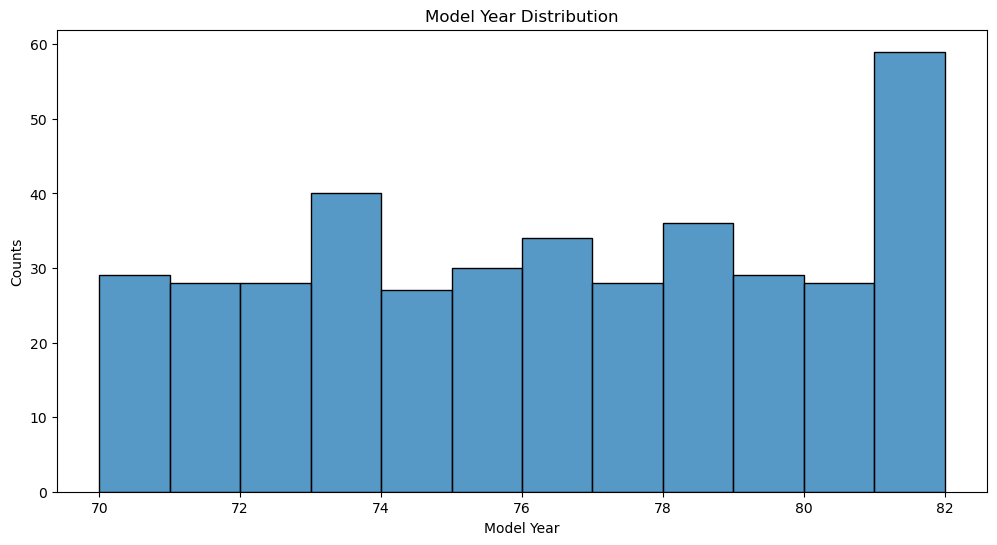

In [120]:
plt.figure(figsize=(12,6))
sns.histplot(df.model_year, bins=12)
plt.xticks()
plt.xlabel("Model Year")
plt.ylabel("Counts")
plt.title("Model Year Distribution")
plt.show()

In [121]:
round(float(df["model_year"].skew()), 2)

0.02

The dataset shows a flat distribution across years, indicating a equivalent sampling throughout the years. 

Years 1981 and 1982 stand out as the years with the most models.

# Bivariate Analysis

To answer the first question ***How does car origin relate to car characteristics?***, the variable origin will be compared with each variable (except car_name and model_year).

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 396 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           396 non-null    float64
 1   cylinders     396 non-null    int64  
 2   displacement  396 non-null    float64
 3   horsepower    396 non-null    float64
 4   weight        396 non-null    int64  
 5   acceleration  396 non-null    float64
 6   model_year    396 non-null    int64  
 7   origin        396 non-null    object 
 8   car_name      396 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 47.1+ KB


In [123]:
my_palette = {
    "USA": "#A6CAEC",
    "Europe": "#F2AA84",
    "Japan": "#8ED973"
}

Analysis of the relation between `origin` and `cylinders`

In [124]:
crosstab_result = pd.crosstab(df['origin'], df['cylinders'])
crosstab_result

cylinders,3,4,5,6,8
origin,,,,,
Europe,0,61,3,4,0
Japan,4,69,0,6,0
USA,0,72,0,74,103


<Figure size 1200x600 with 0 Axes>

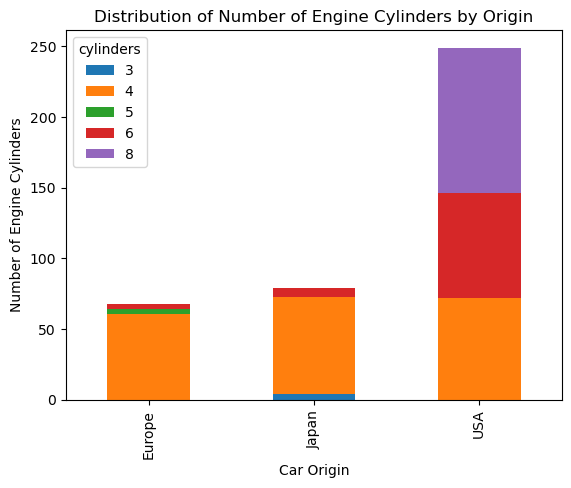

In [125]:
plt.figure(figsize=(12,6))
crosstab_result.plot(kind='bar', stacked=True)
plt.xlabel('Car Origin')
plt.ylabel('Number of Engine Cylinders')
plt.title('Distribution of Number of Engine Cylinders by Origin')

plt.show()

The crosstab shows that almost all cars from Europe and Japan have 4-cylinder engines. 

The majority of cars from the USA have 8-cylinder engines, followed by 6-cyinder engines and then 4-cylinder engines.

Analysis of the relation between `origin` and `mpg`

In [126]:
order_med_mpg = df.groupby('origin')['mpg'].median().sort_values(ascending=True).index

In [127]:
df.groupby('origin')['mpg'].median().sort_values()

origin
USA       18.5
Europe    26.0
Japan     31.6
Name: mpg, dtype: float64

In [128]:
round(df.groupby('origin')['mpg'].describe(), 1)

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
Europe,68.0,27.6,6.6,16.2,23.8,26.0,30.1,44.3
Japan,79.0,30.5,6.1,18.0,25.7,31.6,34.0,46.6
USA,249.0,20.1,6.4,9.0,15.0,18.5,24.0,39.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\1900256273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


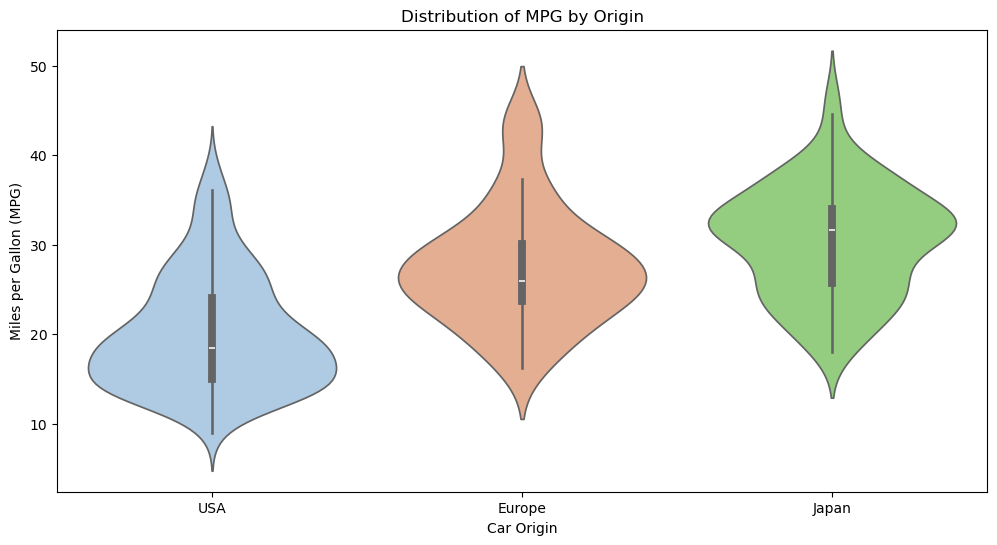

In [129]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='origin',
    y='mpg',
    order=order_med_mpg,
    palette=my_palette
)

plt.xlabel('Car Origin')
plt.ylabel('Miles per Gallon (MPG)')
plt.title('Distribution of MPG by Origin')

plt.show()

Cars from the USA have a lower efficiency, considering the lower average and median MPG values. A high frequency of values is observed ~16-17 mpg.

Japanese cars tend to be the most efficient, with the higest average and median MPG values, with a high frequency of values observed around 33-34 mpg.

European cars present an efficiency between japanese and american car, with values coming closer to the asian counterparts than to americans.

Analysis of the relation between `origin` and `horsepower`

In [130]:
order_med_hp = df.groupby('origin')['horsepower'].median().sort_values(ascending=True).index

In [131]:
df.groupby('origin')['horsepower'].median().sort_values()

origin
Japan      75.0
Europe     76.5
USA       105.0
Name: horsepower, dtype: float64

In [132]:
round(df.groupby('origin')['horsepower'].describe(), 1)

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
Europe,68.0,80.6,20.2,46.0,69.8,76.5,90.0,133.0
Japan,79.0,79.8,17.8,52.0,67.0,75.0,95.0,132.0
USA,249.0,118.5,39.8,52.0,88.0,105.0,150.0,230.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\2993458418.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


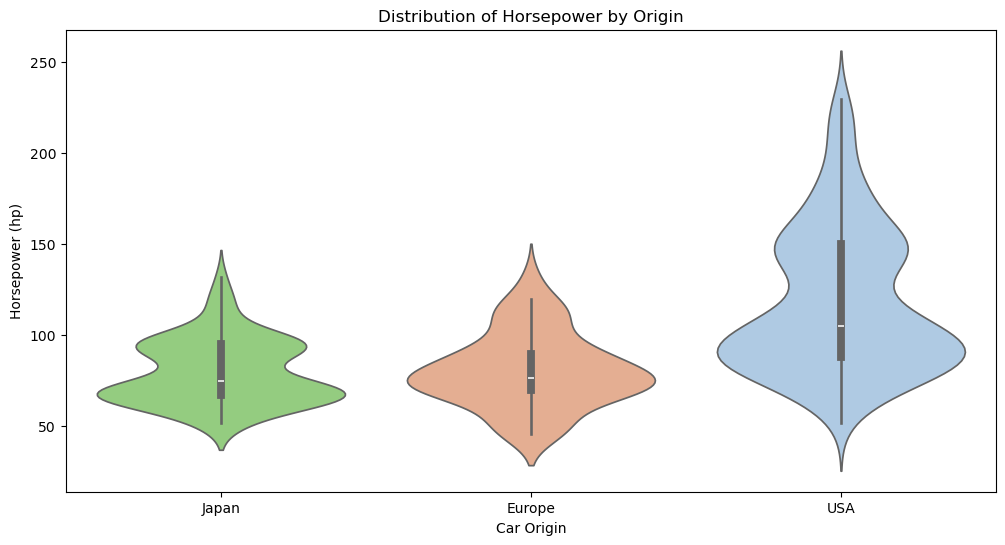

In [133]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='origin',
    y='horsepower',
    order=order_med_hp,
    palette=my_palette
)

plt.xlabel('Car Origin')
plt.ylabel('Horsepower (hp)')
plt.title('Distribution of Horsepower by Origin')

plt.show()

European and japanese cars have a similar distribution of horsepower figures, and similar average and median values. The shape of the distribution are slightly different, with the japanese cars showing two major populations and european just one.

American cars show the highest horsepower figures and the largest spread of values, demonostrating a high variability of horsepower figures.

These results may explain the differences in MPG values previsouly observed.

Analysis of the relation between `origin` and `weight`

In [134]:
order_med_weight = df.groupby('origin')['weight'].median().sort_values(ascending=True).index

In [135]:
df.groupby('origin')['weight'].median().sort_values()

origin
Japan     2155.0
Europe    2240.0
USA       3365.0
Name: weight, dtype: float64

In [136]:
round(df.groupby('origin')['weight'].describe(), 1)

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
Europe,68.0,2433.5,491.8,1825.0,2071.8,2240.0,2803.8,3820.0
Japan,79.0,2221.2,320.5,1613.0,1985.0,2155.0,2412.5,2930.0
USA,249.0,3361.9,794.8,1800.0,2720.0,3365.0,4054.0,5140.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\3123189119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


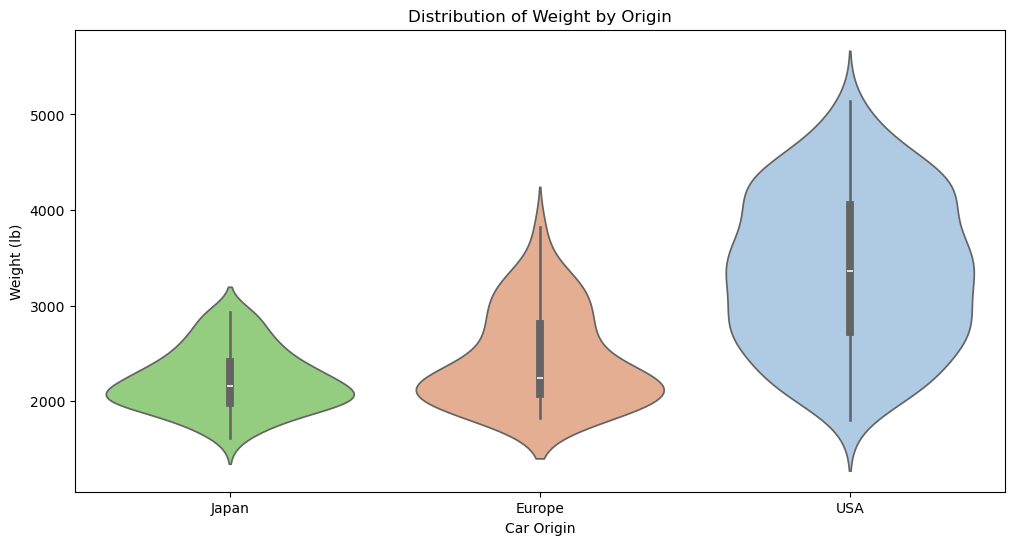

In [137]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='origin',
    y='weight',
    order=order_med_weight,
    palette=my_palette
)

plt.xlabel('Car Origin')
plt.ylabel('Weight (lb)')
plt.title('Distribution of Weight by Origin')

plt.show()

Japanese and european cars tend to be lighter, with the european cars showing a higer spread of weight values, but with relatively similar shapes.

American cars stand-out as the heaviest, with the average and median values significantly higher than its counterparts and a broad distribution in higher weight figures.

This may also be correlated with the lower MPG american car present. And with the horsepower figures, considering car need to be more powerful to compensate the extra weight.

Analysis of the relation between `origin` and `displacement`

In [138]:
order_med_displ = df.groupby('origin')['displacement'].median().sort_values(ascending=True).index

In [139]:
df.groupby('origin')['displacement'].median().sort_values()

origin
Japan      97.0
Europe    105.0
USA       250.0
Name: displacement, dtype: float64

In [140]:
round(df.groupby('origin')['displacement'].describe(), 1)

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
Europe,68.0,109.6,22.7,68.0,94.8,105.0,121.0,183.0
Japan,79.0,102.7,23.1,70.0,86.0,97.0,119.0,168.0
USA,249.0,245.9,98.5,85.0,151.0,250.0,318.0,455.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\1238395311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


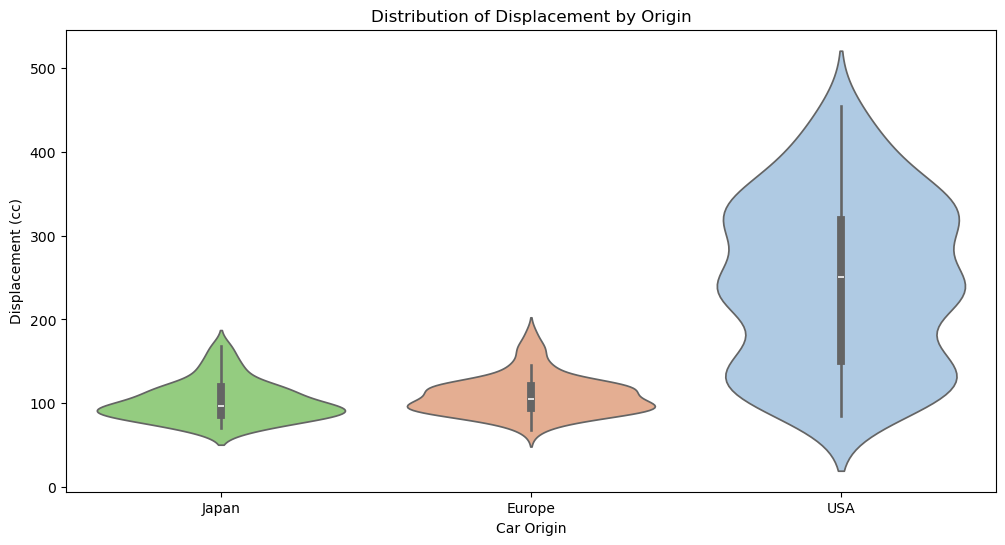

In [141]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='origin',
    y='displacement',
    order=order_med_displ,
    palette=my_palette
)

plt.xlabel('Car Origin')
plt.ylabel('Displacement (cc)')
plt.title('Distribution of Displacement by Origin')

plt.show()

Japanese and european cars have lower engine displacement values, with relatively similar satistical values and distribution.

American cars stand-out as having the largest engine displacement, with the average and median values significantly higher than its counterparts and a broad distribution in higher engine displacement figures. Out of the three principal populations, one is observed in values close to the european and japanese cars, but the remaining two in higher engine displacement figures.

This may also be correlated with the lower MPG values american cars present.

Analysis of the relation between `origin` and `acceleration`

In [142]:
order_med_acc = df.groupby('origin')['acceleration'].median().sort_values(ascending=True).index

In [143]:
df.groupby('origin')['acceleration'].median().sort_values()

origin
USA       15.0
Europe    15.6
Japan     16.4
Name: acceleration, dtype: float64

In [144]:
round(df.groupby('origin')['acceleration'].describe(), 1)

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
Europe,68.0,16.8,3.1,12.2,14.5,15.6,19.1,24.8
Japan,79.0,16.2,2.0,11.4,14.6,16.4,17.6,21.0
USA,249.0,15.0,2.8,8.0,13.0,15.0,16.9,22.2


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\3816958198.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


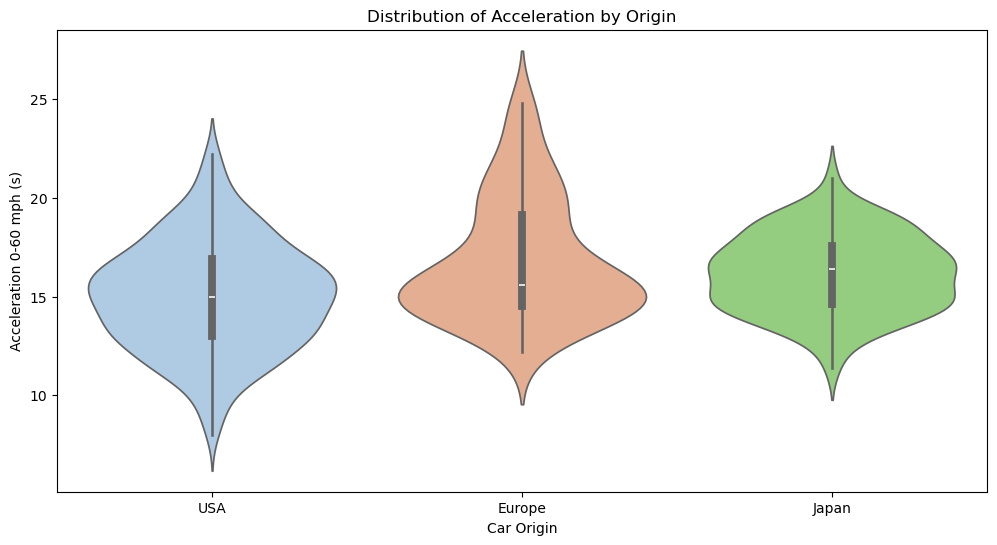

In [145]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='origin',
    y='acceleration',
    order=order_med_acc,
    palette=my_palette
)

plt.xlabel('Car Origin')
plt.ylabel('Acceleration 0-60 mph (s)')
plt.title('Distribution of Acceleration by Origin')

plt.show()

Even though the differences in average and median acceleration values are small, american cars tend to have a faster acceleration than european and japanese cars. This could be due to higher engine power (horsepower) but not as high as possible due to an increase in weight.

European car have a larger spread of acceleration values.

Analysis of the relation between `origin` and `model_year`

In [146]:
order_med_mody = df.groupby('origin')['model_year'].median().sort_values(ascending=True).index

In [147]:
df.groupby('origin')['model_year'].median().sort_values()

origin
Europe    76.0
USA       76.0
Japan     78.0
Name: model_year, dtype: float64

In [148]:
round(df.groupby('origin')['model_year'].describe(), 1)

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
Europe,68.0,75.7,3.4,70.0,73.0,76.0,78.2,82.0
Japan,79.0,77.4,3.7,70.0,74.0,78.0,81.0,82.0
USA,249.0,75.6,3.7,70.0,73.0,76.0,79.0,82.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14180\2054371511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


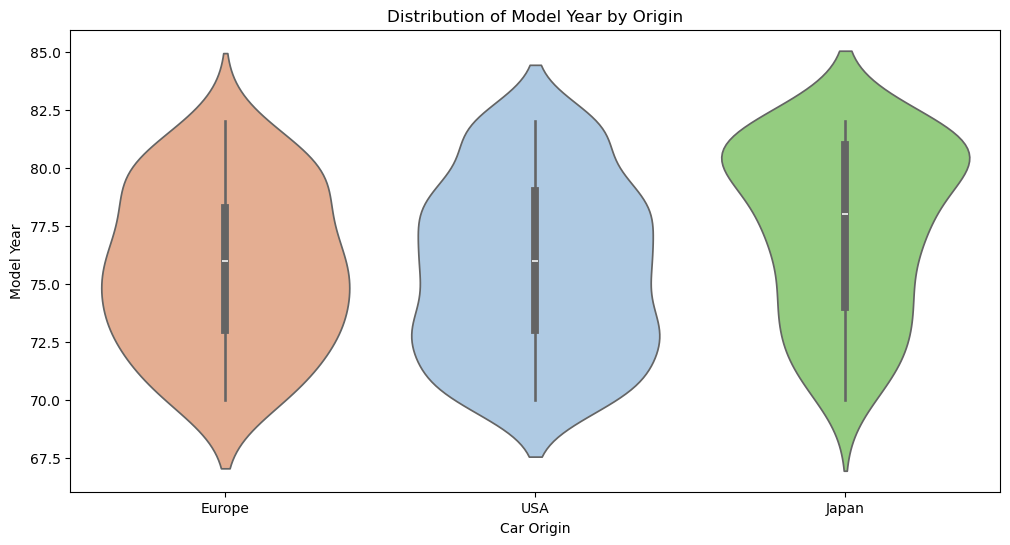

In [149]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='origin',
    y='model_year',
    order=order_med_mody,
    palette=my_palette
)

plt.xlabel('Car Origin')
plt.ylabel('Model Year')
plt.title('Distribution of Model Year by Origin')

plt.show()

Europe and USA have similar statistical parameters in terms of average, median and quartiles, with a similar distribution across different year. Wheres japanese car models tend to be more recent.

# Multivariate Analysis

To answer the second question ***How does car origin influence characteristics evolution over time?***, the variables `origin` and `model_year` will be compared with each variable (except car_name).

Analysis of the relation between `origin`, `model_year`, and `mpg`

In [150]:
palette_multivariate = {
    "USA": "#3274A0",
    "Europe": "#E0802C",
    "Japan": "#3A913A"
}

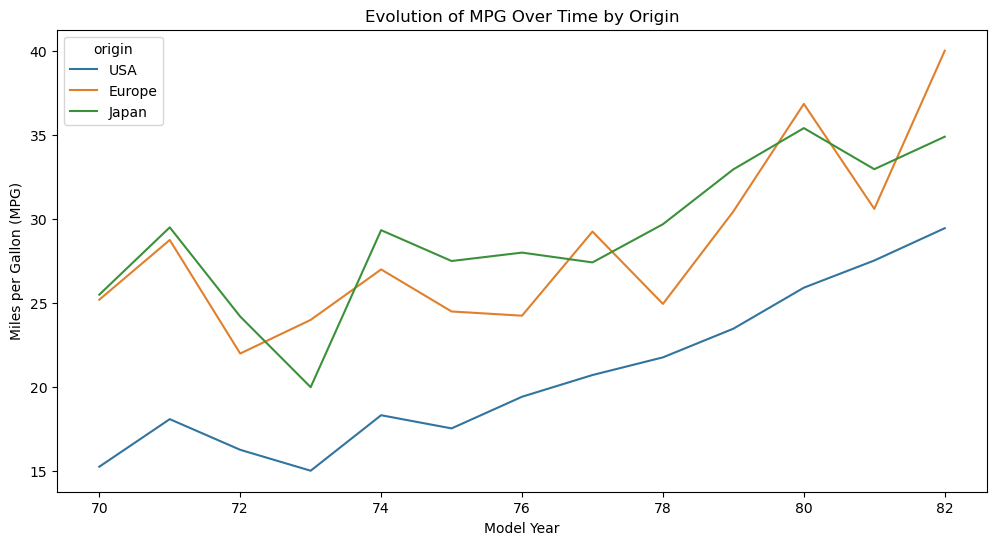

In [151]:
# Aggregating (mean over time + origin)
df_grouped_mpg = df.groupby(['model_year', 'origin'])['mpg'].mean().reset_index()

# Enforcing consistent order (same as box/violin logic)
hue_order = order_med_mpg   # already sorted by median MPG

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_grouped_mpg,
    x='model_year',
    y='mpg',
    hue='origin',
    hue_order=hue_order,
    palette=palette_multivariate
)

# Labels + title
plt.xlabel('Model Year')
plt.ylabel('Miles per Gallon (MPG)')
plt.title('Evolution of MPG Over Time by Origin')

plt.show()

The fuel efficiency of the cars from all origins has improved over time during the considered period (1970-1982).

The evolution of MPG in european and japanese cars was similar in this period, with the european cars distancing themselves towards 1982.

Even though the fuel efficiency of american cars increased, it never reached the values of its counterparts.

* Analysis of the relation between `origin`, `model_year`, and `horsepower`

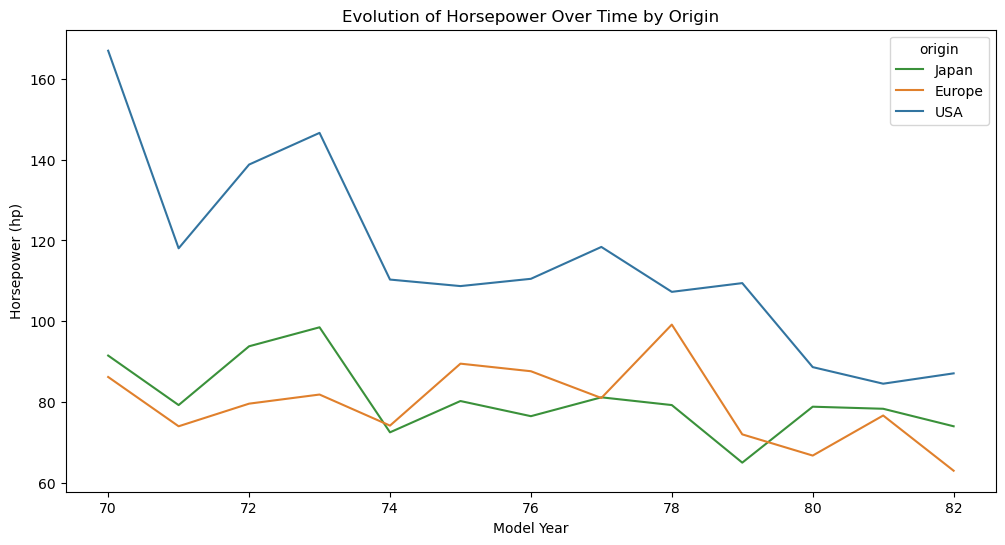

In [152]:
# Aggregating (mean over time + origin)
df_grouped_hp = df.groupby(['model_year', 'origin'])['horsepower'].mean().reset_index()

# Enforcing consistent order (same as box/violin logic)
hue_order = order_med_hp   # already sorted by median MPG

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_grouped_hp,
    x='model_year',
    y='horsepower',
    hue='origin',
    hue_order=hue_order,
    palette=palette_multivariate
)

# Labels + title
plt.xlabel('Model Year')
plt.ylabel('Horsepower (hp)')
plt.title('Evolution of Horsepower Over Time by Origin')

plt.show()

Fluctuations of the average horsepower figures in european and japanese cars were observed, however no noticeable differences were observed among them during the evaluated period.

An overall decrease in the average horsepower of american cars can be observed for the same period.

Analysis of the relation between `origin`, `model_year`, and `weight`

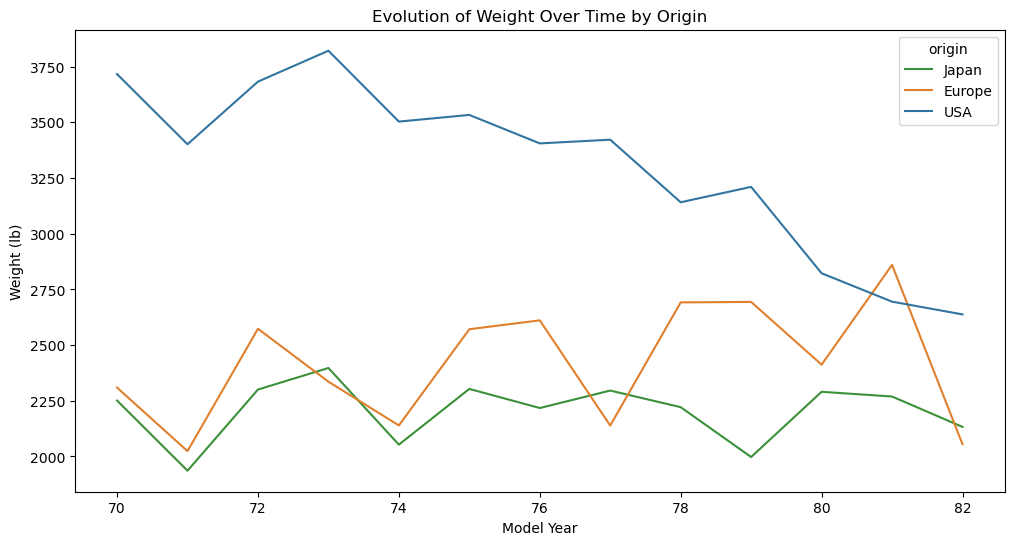

In [153]:
# Aggregating (mean over time + origin)
df_grouped_weight = df.groupby(['model_year', 'origin'])['weight'].mean().reset_index()

# Enforcing consistent order (same as box/violin logic)
hue_order = order_med_weight   # already sorted by median MPG

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_grouped_weight,
    x='model_year',
    y='weight',
    hue='origin',
    hue_order=hue_order,
    palette=palette_multivariate
)

# Labels + title
plt.xlabel('Model Year')
plt.ylabel('Weight (lb)')
plt.title('Evolution of Weight Over Time by Origin')

plt.show()

Japanese cars present fluctuations in average weight over the considered period, however no noticeable variation in this variable was observed.

European cars also present some average weight fluctuations, but seem to demonstrate a tendency to increase in weight over time. Although, a marked decrease in the last year (1982) was observed.

A significant decrease in the average weight of american cars was observed during the considered period.

Analysis of the relation between `origin` and `model_year`, and `displacement`

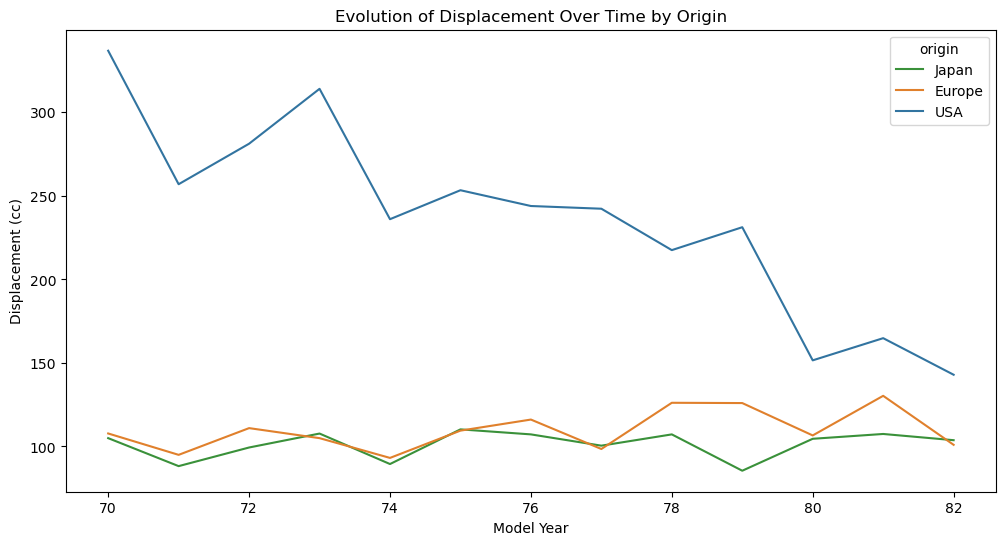

In [154]:
# Aggregating (mean over time + origin)
df_grouped_displ = df.groupby(['model_year', 'origin'])['displacement'].mean().reset_index()

# Enforcing consistent order (same as box/violin logic)
hue_order = order_med_displ   # already sorted by median MPG

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_grouped_displ,
    x='model_year',
    y='displacement',
    hue='origin',
    hue_order=hue_order,
    palette=palette_multivariate
)

# Labels + title
plt.xlabel('Model Year')
plt.ylabel('Displacement (cc)')
plt.title('Evolution of Displacement Over Time by Origin')

plt.show()

The average displacement values of european and japanese cars remained relatively stable during the considered period.

The average displacement values of american cars decreased significantly over the same period.

Analysis of the relation between `origin`, `model_year`, and `acceleration`

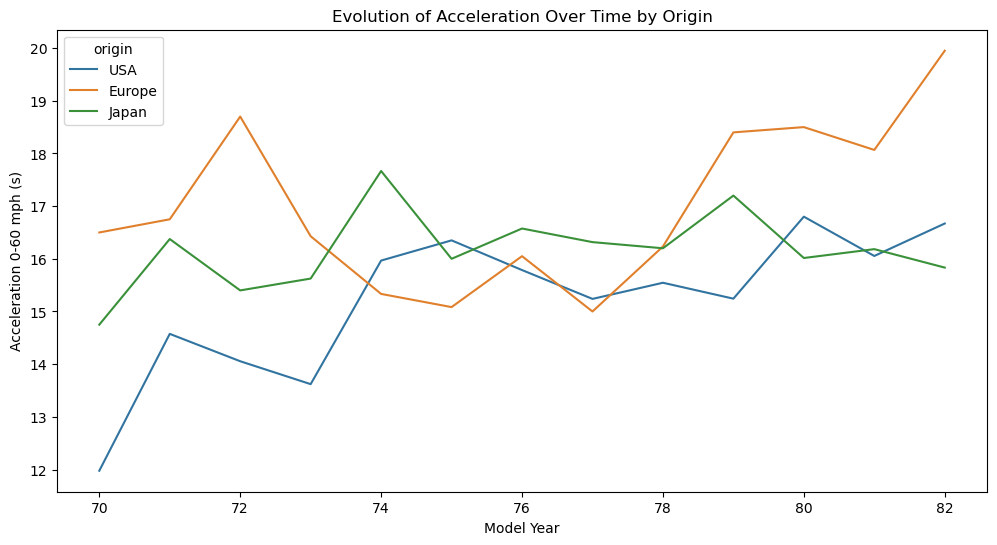

In [155]:
# Aggregating (mean over time + origin)
df_grouped_acc = df.groupby(['model_year', 'origin'])['acceleration'].mean().reset_index()

# Enforcing consistent order (same as box/violin logic)
hue_order = order_med_acc   # already sorted by median MPG

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_grouped_acc,
    x='model_year',
    y='acceleration',
    hue='origin',
    hue_order=hue_order,
    palette=palette_multivariate
)

# Labels + title
plt.xlabel('Model Year')
plt.ylabel('Acceleration 0-60 mph (s)')
plt.title('Evolution of Acceleration Over Time by Origin')
plt.show()

In the earlier years, american cars presented the best acceleration figures, but decreased over time until ~1974-1975, after when remained relatively stable.

European cars started of as having the worst acceleration figures, which improved from aournd 1972 until around 1977, after when they started to decrease until the end of the considered period, showing the worst performance latter years.

Japanese cars figures were the most stable overall during the considered period.

# Future analysis

- Differences in power-weight ratio
- Variation of power-weight ratio over time
- For how long were japanese cars more efficient than european cars
- How did fuel efficiency improved on a yearly basis 

In [156]:
#Export cleaned data to a new csv
#df.to_csv("cleaned_data.csv", index=False)